# Pooling vs Upsample 对比分析

对比两种操作在不同神经网络中的作用和应用场景

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## 1. 核心对比

| 特性 | **Pooling (池化)** | **Upsample (上采样)** |
|------|-------------------|---------------------|
| **方向** | 下采样 (降维) | 上采样 (升维) |
| **空间尺寸** | 减小 (如 28×28 → 14×14) | 增大 (如 14×14 → 28×28) |
| **参数** | 无参数 | 无参数 (固定算法) |
| **用途** | 特征提取、降维 | 图像生成、分割 |
| **信息流** | 压缩信息 | 扩展信息 |
| **典型网络** | CNN、ResNet (编码器) | GAN、U-Net (解码器) |

## 2. Pooling 详解

### 类型

**MaxPooling (最大池化)**
- 取窗口内最大值
- 保留最显著特征
- CNN 中最常用

**AvgPooling (平均池化)**
- 取窗口内平均值
- 保留整体信息
- 更平滑的特征表示

In [3]:
# Pooling 示例

# 创建示例数据
input_data = torch.tensor([
    [1.0, 3.0, 2.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [2.0, 1.0, 3.0, 2.0],
    [4.0, 5.0, 6.0, 7.0]
]).unsqueeze(0).unsqueeze(0)  # (1, 1, 4, 4)

print("原始输入 (4×4):")
print(input_data.squeeze().numpy())
print(f"形状: {input_data.shape}\n")

# MaxPooling
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
# 在每个2D特征图上滑动一个2x2的窗口，取窗口内最大值，每次移动2个像素
output_max = maxpool(input_data)
print("MaxPooling (2×2, stride=2):")
print(output_max.squeeze().numpy())
print(f"形状: {output_max.shape}")
print("✓ 取每个 2×2 窗口的最大值\n")


原始输入 (4×4):
[[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [2. 1. 3. 2.]
 [4. 5. 6. 7.]]
形状: torch.Size([1, 1, 4, 4])

MaxPooling (2×2, stride=2):
[[6. 8.]
 [5. 7.]]
形状: torch.Size([1, 1, 2, 2])
✓ 取每个 2×2 窗口的最大值



## 3. Upsample 详解

### 类型

**Nearest (最近邻)**
- 复制最近像素
- 速度快，有锯齿
- 适合快速原型

**Bilinear (双线性)**
- 周围4个像素加权平均
- 平滑，DCGAN常用
- 速度与质量平衡

**Bicubic (双三次)**
- 周围16个像素加权
- 质量最高，稍慢
- 适合高质量需求

In [4]:
# Upsample 示例

# 使用之前 MaxPooling 的输出
input_small = output_max  # (1, 1, 2, 2)

print("输入 (2×2):")
print(input_small.squeeze().numpy())
print(f"形状: {input_small.shape}\n")

# Nearest Neighbor
upsample_nearest = nn.Upsample(scale_factor=2, mode='nearest')
output_nearest = upsample_nearest(input_small)
print("Nearest Upsample (×2):")
print(output_nearest.squeeze().numpy())
print(f"形状: {output_nearest.shape}")
print("✓ 每个像素复制成 2×2 块\n")

# Bilinear
upsample_bilinear = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
output_bilinear = upsample_bilinear(input_small)
print("Bilinear Upsample (×2):")
print(output_bilinear.squeeze().numpy())
print(f"形状: {output_bilinear.shape}")
print("✓ 双线性插值，更平滑")

输入 (2×2):
[[6. 8.]
 [5. 7.]]
形状: torch.Size([1, 1, 2, 2])

Nearest Upsample (×2):
[[6. 6. 8. 8.]
 [6. 6. 8. 8.]
 [5. 5. 7. 7.]
 [5. 5. 7. 7.]]
形状: torch.Size([1, 1, 4, 4])
✓ 每个像素复制成 2×2 块

Bilinear Upsample (×2):
[[6.   6.5  7.5  8.  ]
 [5.75 6.25 7.25 7.75]
 [5.25 5.75 6.75 7.25]
 [5.   5.5  6.5  7.  ]]
形状: torch.Size([1, 1, 4, 4])
✓ 双线性插值，更平滑


## 4. 在不同网络中的应用

### 4.1 CNN (分类网络)

**使用: Pooling**

```
输入图像 (3, 224, 224)
  ↓
Conv → ReLU → MaxPool  →  (64, 112, 112)
  ↓
Conv → ReLU → MaxPool  →  (128, 56, 56)
  ↓
Conv → ReLU → MaxPool  →  (256, 28, 28)
  ↓
Global AvgPool         →  (256, 1, 1)
  ↓
Linear → 分类结果
```

**作用:**
- 减小空间维度，降低计算量
- 提取抽象特征
- 增大感受野
- 提供平移不变性

In [5]:
# CNN 示例：使用 Pooling 进行特征提取

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28×28 → 14×14
            
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14×14 → 7×7
        )
        self.classifier = nn.Linear(64 * 7 * 7, 10)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# 演示
cnn = SimpleCNN()
x = torch.randn(2, 1, 28, 28)
output = cnn(x)

print("CNN 分类网络 (使用 Pooling)")
print("="*50)
print(f"输入: {x.shape}  (batch=2, 1通道, 28×28)")
print(f"经过特征提取: (2, 64, 7, 7)")
print(f"输出: {output.shape}  (2, 10) - 10个类别的logits")
print("\n✓ Pooling 作用: 逐步降维，提取分类特征")

CNN 分类网络 (使用 Pooling)
输入: torch.Size([2, 1, 28, 28])  (batch=2, 1通道, 28×28)
经过特征提取: (2, 64, 7, 7)
输出: torch.Size([2, 10])  (2, 10) - 10个类别的logits

✓ Pooling 作用: 逐步降维，提取分类特征


### 4.2 GAN Generator (生成网络)

**使用: Upsample**

```
隐向量 z (100,)
  ↓
Linear → Reshape       →  (128, 7, 7)
  ↓
BN → ReLU → Upsample → Conv  →  (128, 14, 14)
  ↓
BN → ReLU → Upsample → Conv  →  (64, 28, 28)
  ↓
BN → ReLU → Conv → Tanh      →  (1, 28, 28)
```

**作用:**
- 从低维生成高维
- 逐步增加空间分辨率
- 填充细节
- 避免棋盘效应 (vs ConvTranspose2d)

### 4.3 AutoEncoder (自编码器)

**使用: 两者都用**

```
编码器 - Pooling 压缩
输入 (1, 28, 28)
  ↓
Conv → ReLU → MaxPool  →  (32, 14, 14)
  ↓
Conv → ReLU → MaxPool  →  (64, 7, 7)
  ↓
Flatten → Linear       →  隐向量 (128,)

解码器 - Upsample 重建
  ↓
Linear → Reshape       →  (64, 7, 7)
  ↓
Upsample → Conv → ReLU →  (32, 14, 14)
  ↓
Upsample → Conv → ReLU →  (16, 28, 28)
  ↓
Conv → Sigmoid         →  重建 (1, 28, 28)
```

**作用:**
- **编码器 (Pooling)**: 压缩到低维表示
- **解码器 (Upsample)**: 从低维重建原图
- **目标**: 学习数据的压缩表示

In [7]:
# GAN Generator 示例：使用 Upsample 生成图像

class SimpleGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(100, 128 * 7 * 7)
        self.main = nn.Sequential(
            # Block 1: 7×7 → 14×14
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 128, 3, padding=1),
            
            # Block 2: 14×14 → 28×28
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            
            # Output
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 128, 7, 7)
        return self.main(x)

# 演示
generator = SimpleGenerator()
z = torch.randn(2, 100)
generated_img = generator(z)

print("GAN Generator (使用 Upsample)")
print("="*50)
print(f"输入: {z.shape}  (batch=2, 100维隐向量)")
print(f"经过上采样: 7×7 → 14×14 → 28×28")
print(f"输出: {generated_img.shape}  (2, 1, 28, 28)")
print(f"值范围: [{generated_img.min():.2f}, {generated_img.max():.2f}]")
print("\n✓ Upsample 作用: 从低维噪声生成高维图像")

GAN Generator (使用 Upsample)
输入: torch.Size([2, 100])  (batch=2, 100维隐向量)
经过上采样: 7×7 → 14×14 → 28×28
输出: torch.Size([2, 1, 28, 28])  (2, 1, 28, 28)
值范围: [-0.84, 0.66]

✓ Upsample 作用: 从低维噪声生成高维图像


## 5. 可视化对比

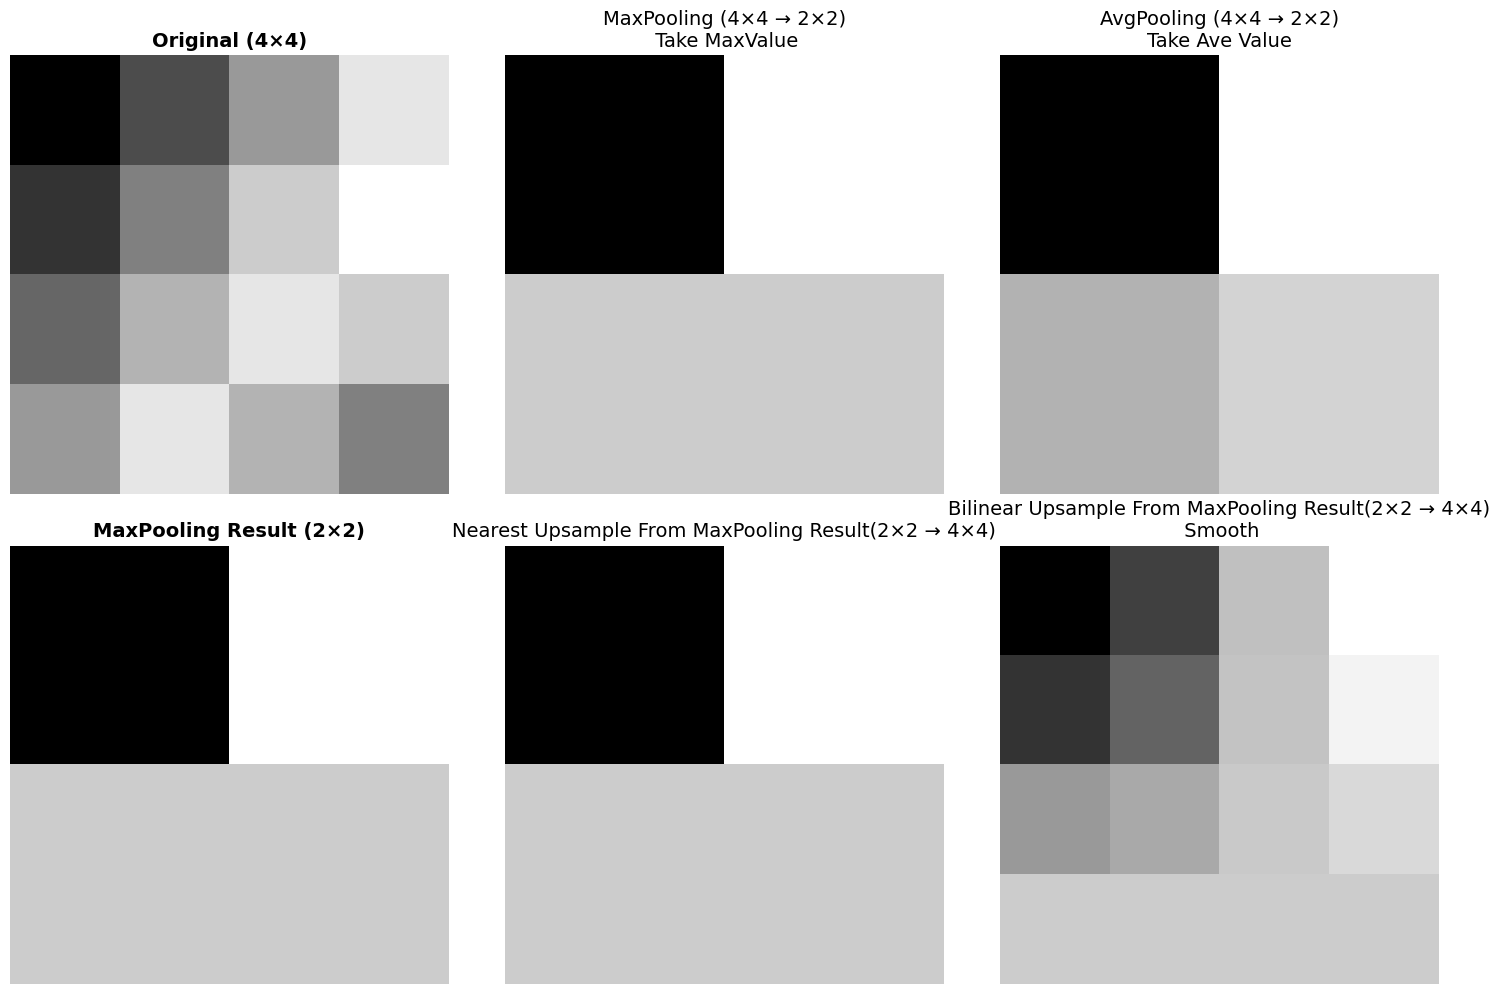


观察:
  • Pooling (上行): 信息压缩，尺寸减小
  • Upsample (下行): 信息扩展，尺寸增大
  • Nearest: 像素复制，有明显边界
  • Bilinear: 插值平滑，过渡自然


In [15]:
# 可视化 Pooling 和 Upsample 的效果

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 创建测试图像
test_img = torch.tensor([
    [0.0, 0.3, 0.6, 0.9],
    [0.2, 0.5, 0.8, 1.0],
    [0.4, 0.7, 0.9, 0.8],
    [0.6, 0.9, 0.7, 0.5]
]).unsqueeze(0).unsqueeze(0)

# 原始图像
axes[0, 0].imshow(test_img.squeeze(), cmap='gray')
axes[0, 0].set_title('Original (4×4)', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# MaxPooling
maxpool = nn.MaxPool2d(2, 2)
pooled_max = maxpool(test_img)
axes[0, 1].imshow(pooled_max.squeeze(), cmap='gray')
axes[0, 1].set_title('MaxPooling (4×4 → 2×2)\n Take MaxValue', fontsize=14)
axes[0, 1].axis('off')

# AvgPooling
avgpool = nn.AvgPool2d(2, 2)
pooled_avg = avgpool(test_img)
axes[0, 2].imshow(pooled_avg.squeeze(), cmap='gray')
axes[0, 2].set_title('AvgPooling (4×4 → 2×2)\nTake Ave Value', fontsize=14)
axes[0, 2].axis('off')

# 使用 MaxPooling 结果进行 Upsample
axes[1, 0].imshow(pooled_max.squeeze(), cmap='gray')
axes[1, 0].set_title('MaxPooling Result (2×2)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# Nearest Upsample
up_nearest = nn.Upsample(scale_factor=2, mode='nearest')
up_result_nearest = up_nearest(pooled_max)
axes[1, 1].imshow(up_result_nearest.squeeze(), cmap='gray')
axes[1, 1].set_title('Nearest Upsample From MaxPooling Result(2×2 → 4×4)', fontsize=14)
axes[1, 1].axis('off')

# Bilinear Upsample
up_bilinear = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
up_result_bilinear = up_bilinear(pooled_max)
axes[1, 2].imshow(up_result_bilinear.squeeze(), cmap='gray')
axes[1, 2].set_title('Bilinear Upsample From MaxPooling Result(2×2 → 4×4)\n Smooth', fontsize=14)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n观察:")
print("  • Pooling (上行): 信息压缩，尺寸减小")
print("  • Upsample (下行): 信息扩展，尺寸增大")
print("  • Nearest: 像素复制，有明显边界")
print("  • Bilinear: 插值平滑，过渡自然")

### 可以看到，Pooling之后，数据丢失，图片尺寸减小，但可以提取一定特征。

### 从Pooling之后的数据，使用Upsample可以重新将图片增大尺寸，但仍然会丢失一部分信息

In [17]:
# AutoEncoder 示例

class SimpleAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器 (Pooling 压缩)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28×28 → 14×14
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14×14 → 7×7
        )
        self.fc_enc = nn.Linear(64 * 7 * 7, 128)
        
        # 解码器 (Upsample 重建)
        self.fc_dec = nn.Linear(128, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 7×7 → 14×14
            
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 14×14 → 28×28
            
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # 编码
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        latent = self.fc_enc(x)
        
        # 解码
        x = self.fc_dec(latent)
        x = x.view(x.size(0), 64, 7, 7)
        reconstructed = self.decoder(x)
        
        return reconstructed, latent

# 演示
ae = SimpleAutoEncoder()
x_original = torch.randn(2, 1, 28, 28)
x_reconstructed, latent = ae(x_original)

print("AutoEncoder (使用 Pooling 和 Upsample)")
print("="*60)
print(f"原始输入: {x_original.shape}")
print(f"\n编码器 (Pooling 压缩):")
print(f"  28×28 → 14×14 → 7×7 → 隐向量 (128,)")
print(f"\n隐向量: {latent.shape}  (压缩表示)")
print(f"\n解码器 (Upsample 重建):")
print(f"  (128,) → 7×7 → 14×14 → 28×28")
print(f"\n重建输出: {x_reconstructed.shape}")

AutoEncoder (使用 Pooling 和 Upsample)
原始输入: torch.Size([2, 1, 28, 28])

编码器 (Pooling 压缩):
  28×28 → 14×14 → 7×7 → 隐向量 (128,)

隐向量: torch.Size([2, 128])  (压缩表示)

解码器 (Upsample 重建):
  (128,) → 7×7 → 14×14 → 28×28

重建输出: torch.Size([2, 1, 28, 28])


## 6. 总结对比表

| 维度 | **Pooling** | **Upsample** |
|------|-------------|--------------|
| **操作类型** | 下采样 (降维) | 上采样 (升维) |
| **空间变化** | 减小 (如 28→14) | 增大 (如 14→28) |
| **信息流向** | 压缩 (丢失细节) | 扩展 (填充细节) |
| **常见方法** | Max, Avg, Global | Nearest, Bilinear, Bicubic |
| **参数数量** | 0 (无需训练) | 0 (固定算法) |
| **计算复杂度** | 低 | 中 (插值计算) |
| **主要应用** | CNN 分类、特征提取 | GAN 生成、图像分割 |
| **网络位置** | 编码器 (Encoder) | 解码器 (Decoder) |
| **信息保留** | 选择性保留 (Max 保留突出特征) | 估算填充 (插值方式决定质量) |
| **可逆性** | 不可逆 (信息丢失) | 伪可逆 (估计值，非原始) |

---

## 关键洞察

### Pooling 的核心作用
1. **降维**: 减少参数和计算量
2. **抽象**: 提取高层次特征
3. **不变性**: 提供平移、旋转不变性
4. **感受野**: 增大感受野，看到更大范围

### Upsample 的核心作用
1. **升维**: 从压缩表示恢复空间信息
2. **生成**: 从低维噪声生成高维图像
3. **定位**: 在分割任务中精确定位像素
4. **平滑**: 避免 ConvTranspose2d 的棋盘效应

### 网络架构选择

**只需要 Pooling:**
- 图像分类 (CNN, ResNet, VGG)
- 目标检测 (YOLO, Faster R-CNN)
- 特征提取网络

**只需要 Upsample:**
- 图像生成 (GAN Generator)
- 超分辨率 (SRGAN)
- 风格迁移

**两者都需要:**
- 图像分割 (U-Net, SegNet)
- 自编码器 (AutoEncoder, VAE)
- 去噪网络 (DnCNN)

## 7. Pooling_vs_Upsample

###  Pooling

    降低空间维度
    提取抽象特征


    丢失精确空间信息


###  Upsample

    图像生成
    恢复分辨率
    预测像素色块

    占用计算资源
